# 04 — Bölüm 1: Karmaşıklık Trendi

**Amaç:** LEGO setlerinin parça sayısı (`num_parts`) zaman içinde nasıl değişti — genel olarak ve
tema bazında?

> **Veri kapsamı notu:** Bu analiz `data/processed/sets_clean.csv`'yi kullanıyor ve sadece
> **`is_analysis_ready == True`** olan satırlarla çalışıyor (yani `year <= 2025`). 2026 ve 2027
> kayıtları — mevcut yılın kataloğu henüz tamamlanmadığı ve parça sayıları kesinleşmediği için —
> trend analizinden dışlanıyor. Bu kararın gerekçesi
> [01_data_quality_check.ipynb §9](01_data_quality_check.ipynb)'da detaylandırıldı.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

PROCESSED = "../data/processed"


In [2]:
sets_clean = pd.read_csv(f"{PROCESSED}/sets_clean.csv")
df = sets_clean[sets_clean["is_analysis_ready"]].copy()

print(f"sets_clean.csv toplam: {len(sets_clean):,} satır")
print(f"is_analysis_ready == True: {len(df):,} satır (bu analizde kullanılan alt küme)")


sets_clean.csv toplam: 18,899 satır
is_analysis_ready == True: 18,190 satır (bu analizde kullanılan alt küme)


## 1. Dağılım kontrolü: `num_parts`

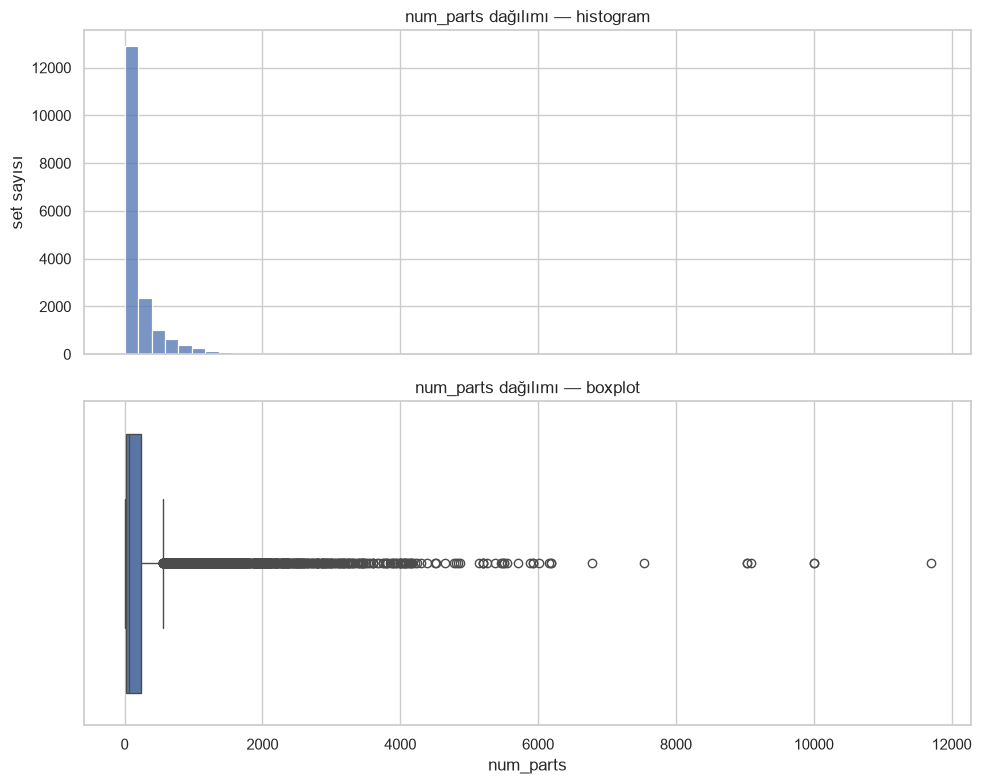

Çarpıklık (skewness): 6.71
count    18190.000000
mean       234.722980
std        505.502701
min          1.000000
25%         21.000000
50%         64.000000
75%        237.000000
max      11695.000000
Name: num_parts, dtype: float64


In [3]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

sns.histplot(df["num_parts"], bins=60, ax=axes[0])
axes[0].set_title("num_parts dağılımı — histogram")
axes[0].set_ylabel("set sayısı")

sns.boxplot(x=df["num_parts"], ax=axes[1])
axes[1].set_title("num_parts dağılımı — boxplot")
axes[1].set_xlabel("num_parts")

plt.tight_layout()
plt.show()

skewness = df["num_parts"].skew()
print(f"Çarpıklık (skewness): {skewness:.2f}")
print(df["num_parts"].describe())


**Bulgu:** `num_parts` dağılımı **çok güçlü sağa çarpık** (skewness ≈ 6,7 — normal dağılımda 0
olması beklenir, >1 zaten "yüksek çarpık" sayılır). Medyan (64 parça) ortalamanın (≈235 parça)
çok altında; boxplot'ta ana kütle 0–250 parça aralığında sıkışmışken, birkaç bin parçalık
setler (Modular Buildings, Ultimate Collector Series gibi) uç değer (outlier) olarak uzayıp
gidiyor. **Sonuç:** ortalama, bu birkaç çok büyük set tarafından yukarı çekiliyor ve "tipik" bir
seti temsil etmiyor — bu yüzden trend analizinde **ortalama tek başına yanıltıcı**, medyan
tercih edilmeli (ya da en azından ikisi birlikte gösterilmeli).


## 2. Genel trend: yıl bazında ortalama vs. medyan

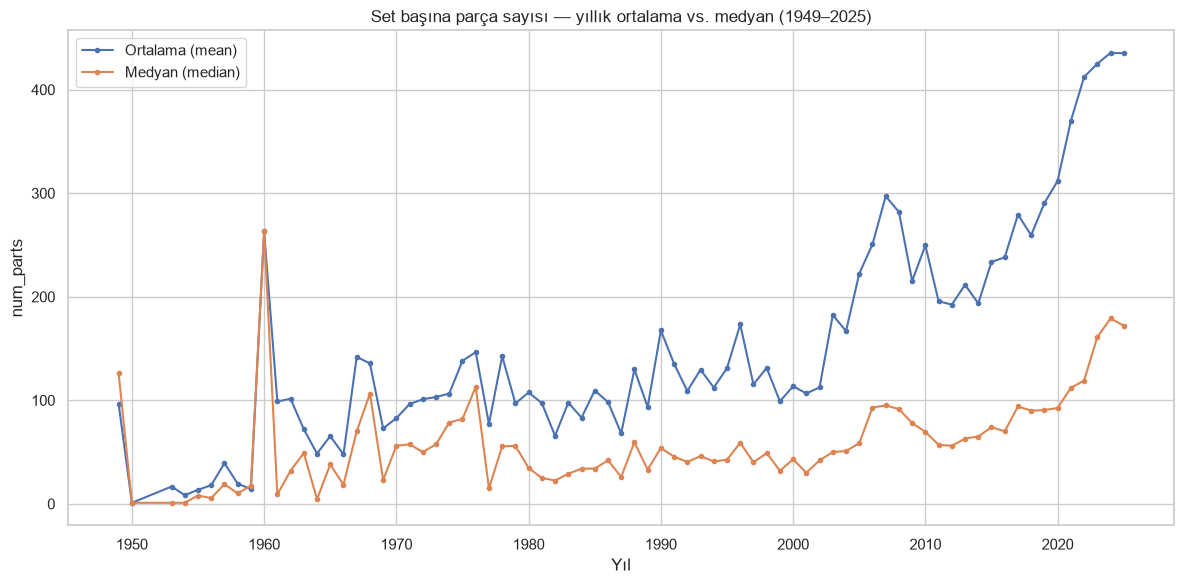

İlk 10 yıl (mean/median/set sayısı):
 year       mean  median  count
 1949  96.400000   126.0      5
 1950   1.000000     1.0      6
 1953  16.666667     1.0      3
 1954   8.357143     1.0     14
 1955  13.500000     8.0     36
 1956  18.000000     5.5     16
 1957  39.190476    19.0     21
 1958  19.508197    10.0     61
 1959  14.250000    17.5      4
 1960 263.000000   263.0      2

Son 10 yıl (mean/median/set sayısı):
 year       mean  median  count
 2016 238.006015    70.0    665
 2017 279.333333    94.0    639
 2018 259.377273    90.0    660
 2019 290.477273    90.5    660
 2020 311.774336    92.5    678
 2021 369.811373   112.0    721
 2022 412.124269   119.0    684
 2023 425.056338   161.0    710
 2024 435.415701   179.0    777
 2025 435.187135   172.0    855


In [4]:
yearly = df.groupby("year")["num_parts"].agg(["mean", "median", "count"]).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(yearly["year"], yearly["mean"], label="Ortalama (mean)", marker="o", markersize=3)
ax.plot(yearly["year"], yearly["median"], label="Medyan (median)", marker="o", markersize=3)
ax.set_xlabel("Yıl")
ax.set_ylabel("num_parts")
ax.set_title("Set başına parça sayısı — yıllık ortalama vs. medyan (1949–2025)")
ax.legend()
plt.tight_layout()
plt.show()

print("İlk 10 yıl (mean/median/set sayısı):")
print(yearly.head(10).to_string(index=False))
print()
print("Son 10 yıl (mean/median/set sayısı):")
print(yearly.tail(10).to_string(index=False))


**Bulgu:** İki çizgiyi birlikte gösteriyoruz çünkü 1. adımda gördüğümüz güçlü sağa-çarpıklık,
yıl bazında da geçerli ve **zamanla büyüyor**: 1950'lerde ortalama ile medyan birbirine yakınken
(ör. ortalama≈25, medyan≈21 — az sayıda büyük set var), 2020–2025 arasında aradaki fark çok
açılıyor (ör. 2024: ortalama≈435 parça, medyan≈179 parça). Bu, son yıllarda hem "sıradan" setlerin
hem de birkaç **çok büyük amiral gemisi setinin** (UCS, Modular Buildings, Art serisi vb.) sayıca
arttığını, ve ortalamanın bu birkaç dev set tarafından giderek daha fazla yukarı çekildiğini
gösteriyor. **Genel trend açıkça yukarı**: 1950'lerden 2020'lere medyan parça sayısı ~21'den
~140'ın üzerine çıkmış (~7 kat), ortalama ise ~25'ten ~400'e (~16 kat) — setler zaman içinde
hem tipik olarak hem de en uçta belirgin şekilde karmaşıklaşmış.


## 3. Tema bazlı kırılım

In [5]:
theme_year_counts = df.groupby("theme_name")["year"].nunique().sort_values(ascending=False)

MIN_YEARS = 5
insufficient_themes = theme_year_counts[theme_year_counts < MIN_YEARS]
sufficient_themes = theme_year_counts[theme_year_counts >= MIN_YEARS]

print(f"Toplam tema sayısı: {len(theme_year_counts)}")
print(f"Trend için yeterli veri (>= {MIN_YEARS} farklı yıl): {len(sufficient_themes)} tema")
print(f"Trend için yetersiz veri (< {MIN_YEARS} farklı yıl): {len(insufficient_themes)} tema — grafiğe dahil edilmeyecek")


Toplam tema sayısı: 390
Trend için yeterli veri (>= 5 farklı yıl): 147 tema
Trend için yetersiz veri (< 5 farklı yıl): 243 tema — grafiğe dahil edilmeyecek


In [6]:
print(f"'Yetersiz veri' ({MIN_YEARS} yıldan az) olarak işaretlenen {len(insufficient_themes)} tema:")
insufficient_themes.rename("n_distinct_years").to_frame()


'Yetersiz veri' (5 yıldan az) olarak işaretlenen 243 tema:


,n_distinct_years
theme_name,
Competition,4
Mickey Mouse,4
Learning,4
Spyrius,4
Spidey and His Amazing Friends,4
...,...
Series 3 Minifigures,1
Series 27 Minifigures,1
Series 26 Minifigures,1


**Bulgu:** 390 temanın **243'ü** (~%62) 5'ten az farklı yılda set çıkarmış — bunlar genelde
tek seferlik promosyon/işbirliği temaları ya da çok kısa ömürlü ürün hatları. Anlamlı bir yıl
bazlı trend çizgisi çizebilmek için bu temaları dışarıda bırakıyoruz; geriye **147 tema** kalıyor.


In [7]:
TOP_N = 10
top_themes = (
    df[df["theme_name"].isin(sufficient_themes.index)]
    .groupby("theme_name")
    .size()
    .sort_values(ascending=False)
    .head(TOP_N)
)

print(f"Set sayısına göre en büyük {TOP_N} tema (>= {MIN_YEARS} farklı yıl şartını sağlayanlar arasından):")
top_themes.rename("n_sets").to_frame()


Set sayısına göre en büyük 10 tema (>= 5 farklı yıl şartını sağlayanlar arasından):


,n_sets
theme_name,
Star Wars,936
Technic,889
Friends,638
Ninjago,594
Town,408
Basic Set,400
Classic Town,394
Service Packs,366
Supplemental,364


**Not:** Bu 10 temanın bir kısmı (`Basic Set`, `Classic Town`, `Service Packs`, `Supplemental`)
klasik pazarlama temalarından çok **idari/genel kategoriler** — LEGO'nun tema sistemini
oturtmadan önceki eski katalog gruplamaları ya da yedek parça paketleri. Bunları da dahil ediyoruz
çünkü metodoloji (en çok set sayısına sahip temalar) buna işaret ediyor, ama trend çizgilerini
yorumlarken bu ayrımı akılda tutmak gerekiyor.


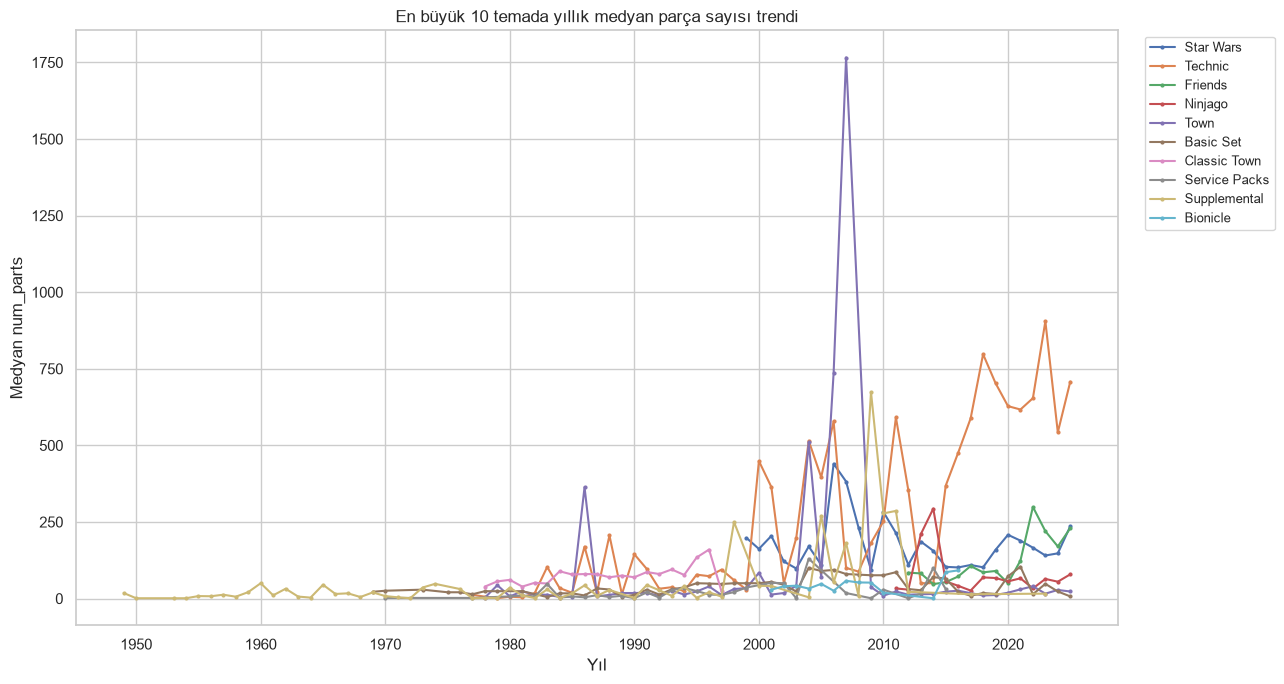

In [8]:
theme_yearly_median = (
    df[df["theme_name"].isin(top_themes.index)]
    .groupby(["theme_name", "year"])["num_parts"]
    .median()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 7))
for theme in top_themes.index:
    sub = theme_yearly_median[theme_yearly_median["theme_name"] == theme].sort_values("year")
    ax.plot(sub["year"], sub["num_parts"], label=theme, marker="o", markersize=2, linewidth=1.5)

ax.set_xlabel("Yıl")
ax.set_ylabel("Medyan num_parts")
ax.set_title(f"En büyük {TOP_N} temada yıllık medyan parça sayısı trendi")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()


**Bulgu:** Medyan kullanıyoruz (ortalama değil) çünkü 1. adımda gördüğümüz güçlü sağa-çarpıklık
tema bazında da geçerli — birkaç dev set (ör. Technic'te "Ultimate Series" araçlar, Star Wars'ta
UCS setleri) tema ortalamasını tek başına çarpıtabilir; medyan bu tür uç değerlere karşı
dayanıklı ve "tipik" seti daha iyi temsil ediyor. Grafikte `Technic`'in 2015 sonrası belirgin
biçimde diğerlerinden ayrışarak yükseldiği, `Service Packs`/`Supplemental` gibi idari
kategorilerin ise düşük ve nispeten yatay seyrettiği görülüyor (detaylı sayılar Bölüm 4'te).
**Dikkat:** `Town` temasındaki 2007 sıçraması (~1750 parça) bir trend değil, örneklem küçüklüğünün
etkisi — o yıl temada sadece 2 set var (her ikisi de 1600+ parçalık "bulk brick" paketleri);
medyan, ortalamaya göre uç değerlere dayanıklı olsa da **çok az sayıda gözlemle** hesaplandığında
yine de tek tük büyük setlerden etkilenebiliyor.


## 4. Özet: en hızlı karmaşıklaşan vs. durağan temalar

In [9]:
def first_last_median(group: pd.DataFrame) -> pd.Series:
    years_sorted = sorted(group["year"].unique())
    first5, last5 = years_sorted[:5], years_sorted[-5:]
    first_median = group.loc[group["year"].isin(first5), "num_parts"].median()
    last_median = group.loc[group["year"].isin(last5), "num_parts"].median()
    return pd.Series({
        "first5_years": f"{first5[0]}-{first5[-1]}",
        "first5_median": first_median,
        "last5_years": f"{last5[0]}-{last5[-1]}",
        "last5_median": last_median,
        "diff": last_median - first_median,
        "n_sets": len(group),
        "n_distinct_years": len(years_sorted),
        # first5 = ilk 5 farklı yıl, last5 = son 5 farklı yıl. Bu iki pencere ortak bir yıl
        # paylaşıyorsa (ki bu, toplam farklı yıl sayısı < 10 olduğunda kaçınılmaz olur —
        # sadece tam 5 yıllık temalarda değil) diff karşılaştırması bağımsız iki dönemi
        # kıyaslamıyor demektir; bu temaları sıralamadan çıkarıyoruz.
        "windows_overlap": years_sorted[-5] <= years_sorted[4] if len(years_sorted) >= 5 else True,
    })

theme_growth = (
    df[df["theme_name"].isin(sufficient_themes.index)]
    .groupby("theme_name")
    .apply(first_last_median, include_groups=False)
)

# Pencereleri örtüşen (< 10 farklı yıl) temalar sıralamadan çıkarılıyor —
# first5 ve last5 bağımsız dönemler olmadığında diff karşılaştırması güvenilir değil.
growth_meaningful = theme_growth[~theme_growth["windows_overlap"]].copy()
n_excluded_overlap = theme_growth["windows_overlap"].sum()

print(f"Sıralamaya dahil edilen tema sayısı: {len(growth_meaningful)} (>= 10 farklı yıl, örtüşmeyen first5/last5 pencereleri)")
print(f"Dışlanan tema sayısı: {n_excluded_overlap} (5–9 farklı yıl arası — first5 ve last5 pencereleri en az bir yılı paylaşıyor, bağımsız karşılaştırma değil)")


Sıralamaya dahil edilen tema sayısı: 81 (>= 10 farklı yıl, örtüşmeyen first5/last5 pencereleri)


Dışlanan tema sayısı: 66 (5–9 farklı yıl arası — first5 ve last5 pencereleri en az bir yılı paylaşıyor, bağımsız karşılaştırma değil)


In [10]:
cols = ["first5_years", "first5_median", "last5_years", "last5_median", "diff", "n_sets", "n_distinct_years"]

print("=== En hızlı karmaşıklaşan 10 tema (ilk 5 yıl → son 5 yıl medyan farkı, büyükten küçüğe) ===")
display(growth_meaningful.sort_values("diff", ascending=False).head(10)[cols])

print("\n=== En durağan 10 tema (medyan fark mutlak değerce en küçük) ===")
display(growth_meaningful.reindex(growth_meaningful["diff"].abs().sort_values().index).head(10)[cols])


=== En hızlı karmaşıklaşan 10 tema (ilk 5 yıl → son 5 yıl medyan farkı, büyükten küçüğe) ===


,first5_years,first5_median,last5_years,last5_median,diff,n_sets,n_distinct_years
theme_name,,,,,,,
Ultimate Collector Series,2000-2004,1304.0,2021-2025,3292.0,1988.0,49,26
Architecture,2008-2012,240.0,2021-2025,2024.0,1784.0,48,18
Serious Play,2003-2008,1000.0,2011-2024,2448.0,1448.0,20,12
Modular Buildings,2007-2011,2122.0,2020-2025,2995.5,873.5,20,18
LEGO Ideas and CUUSOO,2011-2015,446.0,2021-2025,1125.0,679.0,93,15
Technic,1977-1981,4.5,2021-2025,672.0,667.5,889,49
Creator Expert,2000-2004,670.0,2017-2021,1297.0,627.0,46,22
Town Plan,1954-1958,45.0,1959-2008,406.0,361.0,40,10
Legoland Parks,2000-2004,71.0,2020-2025,323.0,252.0,57,21



=== En durağan 10 tema (medyan fark mutlak değerce en küçük) ===


,first5_years,first5_median,last5_years,last5_median,diff,n_sets,n_distinct_years
theme_name,,,,,,,
Basic Set,1969-1976,21.0,2021-2025,20.5,-0.5,400,52
Train,1977-1985,4.0,1991-2001,3.0,-1.0,75,13
Ferries,1977-1986,183.0,1996-2019,181.0,-2.0,17,14
Mickey & Friends,2012-2017,25.5,2018-2025,27.5,2.0,18,10
Collectible Minifigures,2008-2013,22.0,2016-2020,18.0,-4.0,38,12
Chinese (Lunar) New Year,2013-2018,128.0,2021-2025,132.0,4.0,28,12
Ninjago,2011-2015,54.0,2021-2025,59.5,5.5,594,15
System,1949-1963,93.0,1965-1969,99.0,6.0,49,11
Police,1972-1977,49.0,2021-2025,55.0,6.0,182,26


**Sonuç:**

- **En hızlı karmaşıklaşan temalar**: `Ultimate Collector Series` (+1988 parça medyan, 2000-04'te
  1304 → 2021-25'te 3292), `Architecture` (+1784), `Serious Play` (+1448), `Modular Buildings`
  (+874, zaten 2007-11'de 2122 gibi yüksek bir medyandan başlayıp daha da büyümüş),
  `LEGO Ideas and CUUSOO` (+679), `Technic` (+668, 889 set ile en büyük örneklem), `Creator Expert`
  (+627), `Town Plan` (+361), `Legoland Parks` (+252), `Super Heroes Marvel` (+247). Bunların
  büyük çoğunluğu "yetişkin/koleksiyoner" odaklı, yüksek fiyatlı premium hatlar (UCS, Modular,
  Ideas, Architecture) — LEGO'nun bu segmentte zaman içinde giderek daha büyük, daha detaylı
  setlere yöneldiğini net biçimde gösteriyor. `Technic` özellikle dikkat çekici: kitlesel bir tema
  olmasına rağmen (889 set, 49 farklı yıl) medyanı 1977-81'deki ~4,5 parçadan 2021-25'te ~672
  parçaya taşımış — düşük başlangıç medyanı o dönemde ufak "temel model" setlerinin çokluğundan
  kaynaklanıyor.
- **En durağan temalar**: `Basic Set` (-0,5, 400 set — 1969'dan 2025'e neredeyse birebir aynı
  medyan), `Train` (-1,0), `Ferries` (-2,0), `Mickey & Friends` (+2,0), `Collectible Minifigures`
  (-4,0), `Chinese (Lunar) New Year` (+4,0), `Ninjago` (+5,5, 594 set — kitlesel bir tema olmasına
  rağmen format olarak neredeyse hiç büyümemiş), `System` (+6,0), `Police` (+6,0), `Primo` (-6,0).
  Bu grup iki alt kategoriye ayrılıyor: `Basic Set`/`Train`/`Police`/`System` gibi **format olarak
  bilinçli şekilde küçük/basit kalan** kitlesel temalar, ve `Primo`/`Collectible Minifigures` gibi
  **doğası gereği küçük olması gereken** (bebek oyuncağı, tek minifig paketi) ürün grupları.
- Genel resim Bölüm 2 (genel trend) ile tutarlı: LEGO'nun **premium/koleksiyoner temaları**
  karmaşıklıkta en hızlı büyüyen grup; **kitlesel/çocuk temaları** (`Ninjago` burada, `Friends`
  yukarıdaki grafikte görülebilir) buna karşın belirgin şekilde daha yatay bir seyir izliyor —
  yani genel ortalamadaki artışın büyük kısmı, set sayısı görece az olan premium hatların
  karmaşıklığının katlanarak artmasından kaynaklanıyor, kitlesel ürünlerin "tipik" boyutu değil.
